# Module 6 — Analyzing & Interpreting Results

Part of the **A/B Testing Playbook** learning program. Full program context, progress tracker, and how this module fits with the rest: see `CURRICULUM.md`.

## From the curriculum

> **Concepts**
> - Statistical significance vs. practical/business significance — p < 0.05 with a trivial effect size is not a reason to ship
> - Heterogeneous treatment effects — does the effect differ by segment, and when is segment-cutting legitimate vs. p-hacking (ties directly back to Module 5's multiple-comparisons problem)
> - Interpreting ambiguous or flat/failed experiments — a non-significant result is information, not a failure of the analysis
> - Interference/network effects — when treatment and control users affect each other (marketplaces, social features), breaking the independence assumption the stats in Module 3 rely on
>
> **Why it matters**
> This is where most real-world analytical mistakes happen — not in running the test, but in over- or under-interpreting the result afterward. It's also a frequent interview "gotcha" because it's easy to sound rigorous and still get it wrong.
>
> **Worked example**
> A test shows no significant overall effect, but slicing by "new users" shows a significant lift. Is that real? On its own, no — if you didn't pre-specify that segment, you're implicitly running many tests (Module 5's problem again) and some will look significant by chance. What would make it credible: the segment was hypothesized *before* the test, the effect direction is consistent with a plausible mechanism, and ideally it replicates in a follow-up test scoped to that segment.
>
> **Resources**
> - *Trustworthy Online Controlled Experiments* — Kohavi, Tang, Xu, Ch. 4 and Ch. 20/21 on segmentation and interpreting results (~30 min combined) — no free web version, requires the book itself (same as Module 3's Ch. 3).
>
> **Exercise type:** given a results table with some real pattern and some traps baked in, diagnose what's actually going on.
>
> **Interview angle:** "the test showed a significant result in one segment but not overall — what do you conclude?" — classic trap question.

## Lesson

### Statistical significance vs. practical significance

These answer two completely different questions. **Statistical significance** asks "is this gap probably not just noise?" — a yes/no call driven heavily by sample size. **Practical (business) significance** asks "is this gap big enough to care about?" — a judgment call about the real world, completely independent of how much data you collected. The two can point in *either* direction independently: a big enough sample turns a genuinely trivial effect into a statistically significant one (Part 1's Test A), and a genuinely large effect can fail to reach significance simply because the sample was too small to pin it down precisely (Part 1's Test B). Neither p-value alone tells you which situation you're in — you have to look at the actual effect size and its confidence interval.

### Heterogeneous treatment effects and segment-cutting

Module 5 already gave you the machinery: cutting results by many segments after the fact is the exact same multiple-comparisons problem as testing many metrics — some segment, somewhere, will look significant purely by chance. That doesn't mean segment analysis is illegitimate; it means a segment finding needs the same discipline Module 4 asked of the whole experiment: was this segment **hypothesized before** the test (not found by trawling through a dozen cuts afterward)? Is there a **plausible mechanism** for why this specific segment would behave differently? Would it **replicate** in a dedicated follow-up test? A segment finding with all three is a real lead. A segment finding with none of them is Module 5's inflated false-positive rate, dressed up as an insight.

### Interpreting ambiguous or flat results

A p-value above 0.05 does **not** mean "we proved there's no effect" — it means "we didn't gather enough evidence to distinguish a real effect from noise, at this sample size." Those are very different claims. A wide confidence interval that straddles zero (Part 1's Test B) is genuinely ambiguous: it's consistent with a real, meaningful effect *and* with no effect at all, and the honest answer is "inconclusive," not "no." The wrong move is reporting a flat result as proof the change doesn't work; the right move is reporting what the data can and can't rule out, and deciding whether it's worth a bigger sample to find out.

### Interference and network effects

Every test in this program so far has leaned on one quiet assumption: what happens to a control user doesn't depend on what treatment users are doing. That assumption has a name — **SUTVA** (Stable Unit Treatment Value Assumption) — and it breaks whenever units can affect each other: a marketplace where treatment listings compete with control listings for the same limited buyer demand, a social feature where a treatment user's activity shows up in a control friend's feed, a two-sided market where paying one side more leaves less for the other side. When SUTVA breaks, "control" stops being a clean untouched baseline, and the standard comparison can be biased in either direction — Part 4 builds a concrete case where it *overstates* the true effect, because the gain measured for treatment is partly just taken away from control, not created from nothing.

### Part 1 — Statistical vs. practical significance, side by side

Two tests. Test A has a huge sample and a tiny true effect. Test B has a small sample and a large true effect. Which one is "significant" turns out to depend almost entirely on sample size, not on which effect actually matters more in the real world.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# each part below seeds its own rng explicitly (rng_a, rng_b, rng_table, rng_4) --
# no shared/sequential rng here, so adding or reordering a cell can't silently
# change another part's "random" numbers

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GOOD = "#1a7f37"
BAD = "#cf222e"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

def z_test_pvalue(x1, n1, x2, n2):
    """Two-proportion z-test p-value -- same formula validated from scratch in Module 3."""
    p1, p2 = x1 / n1, x2 / n2
    p_pooled = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n1 + 1 / n2))
    se_safe = np.where(se == 0, 1, se)
    z = np.where(se == 0, 0, (p2 - p1) / se_safe)
    return 2 * (1 - stats.norm.cdf(np.abs(z)))

def ci95_diff(x1, n1, x2, n2):
    p1, p2 = x1 / n1, x2 / n2
    se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    diff = p2 - p1
    z = stats.norm.ppf(0.975)
    return diff - z * se, diff + z * se

In [2]:
# Test A: huge sample (400,000/arm), TINY true effect (5.00% -> 5.15%)
rng_a = np.random.default_rng(7)
n_a = 400_000
c_a = rng_a.binomial(n_a, 0.0500)
t_a = rng_a.binomial(n_a, 0.0515)
p_a = z_test_pvalue(c_a, n_a, t_a, n_a)
lo_a, hi_a = ci95_diff(c_a, n_a, t_a, n_a)

# Test B: small sample (200/arm), LARGE true effect (5% -> 9%)
rng_b = np.random.default_rng(2)
n_b = 200
c_b = rng_b.binomial(n_b, 0.05)
t_b = rng_b.binomial(n_b, 0.09)
p_b = z_test_pvalue(c_b, n_b, t_b, n_b)
lo_b, hi_b = ci95_diff(c_b, n_b, t_b, n_b)

summary = pd.DataFrame({
    "n per arm": [n_a, n_b],
    "observed lift (pp)": [(t_a - c_a) / n_a * 100, (t_b - c_b) / n_b * 100],
    "95% CI (pp)": [f"({lo_a*100:+.2f}, {hi_a*100:+.2f})", f"({lo_b*100:+.2f}, {hi_b*100:+.2f})"],
    "p-value": [p_a, p_b],
    "statistically significant?": [p_a < 0.05, p_b < 0.05],
}, index=["Test A (huge n, tiny true effect)", "Test B (small n, large true effect)"])
summary

,n per arm,observed lift (pp),95% CI (pp),p-value,statistically significant?
"Test A (huge n, tiny true effect)",400000,0.119,"(+0.02, +0.22)",0.015127,True
"Test B (small n, large true effect)",200,4.000,"(-0.64, +8.64)",0.092123,False


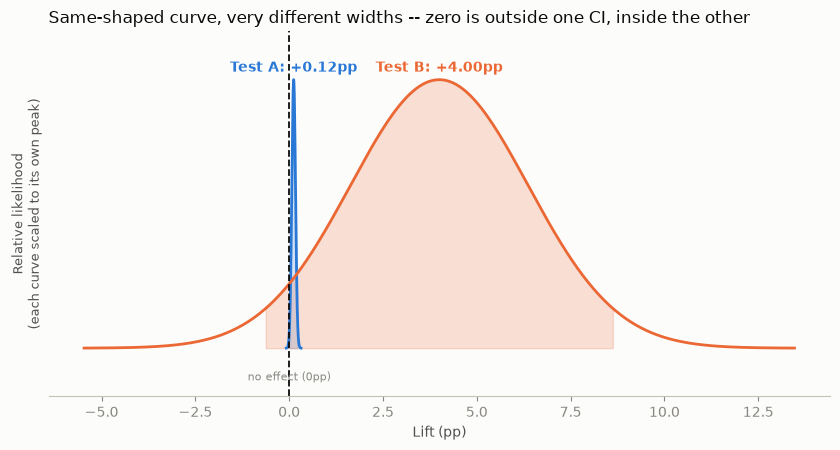

In [3]:
se_a = (hi_a - lo_a) / (2 * stats.norm.ppf(0.975))
se_b = (hi_b - lo_b) / (2 * stats.norm.ppf(0.975))
mean_a, mean_b = (t_a - c_a) / n_a * 100, (t_b - c_b) / n_b * 100
se_a_pp, se_b_pp = se_a * 100, se_b * 100

fig, ax = plt.subplots(figsize=(8.5, 4.6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

# ONE shared x-axis (pp) for both. Each curve is normalized to its OWN peak = 1 --
# that's a per-curve data transform, not a second axis -- needed because Test A's
# curve (n=400,000) would otherwise be ~45x taller than Test B's (n=200) and
# effectively invisible on a shared, non-normalized y-scale.
for label, mean, se, color in [("Test A", mean_a, se_a_pp, BLUE), ("Test B", mean_b, se_b_pp, ORANGE)]:
    x = np.linspace(mean - 4 * se, mean + 4 * se, 400)
    y = stats.norm.pdf(x, loc=mean, scale=se)
    y_norm = y / y.max()
    ax.plot(x, y_norm, color=color, linewidth=2)
    ci_mask = (x >= mean - 1.96 * se) & (x <= mean + 1.96 * se)
    ax.fill_between(x[ci_mask], y_norm[ci_mask], color=color, alpha=0.2)
    ax.annotate(f"{label}: {mean:+.2f}pp", xy=(mean, 1.03), ha="center", fontsize=10, color=color, fontweight="bold")

ax.axvline(0, color=INK, linewidth=1.3, linestyle="--")
ax.annotate("no effect (0pp)", xy=(0, -0.12), ha="center", fontsize=8, color=INK_MUTED)

ax.set_xlabel("Lift (pp)", color=INK_SECONDARY)
ax.set_ylabel("Relative likelihood\n(each curve scaled to its own peak)", color=INK_SECONDARY, fontsize=9)
ax.set_ylim(-0.18, 1.18)
ax.set_title("Same-shaped curve, very different widths -- zero is outside one CI, inside the other", color=INK, fontsize=12, loc="left")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, left=False, labelleft=False)

plt.tight_layout()
plt.show()

**What this shows:** Test A is statistically significant (p < 0.05) with a lift of roughly +0.12 percentage points — real, detectable, and almost certainly too small to justify shipping on its own merits; the CI itself (about 0.02 to 0.22pp) confirms the true effect is small even at the high end. Test B is *not* statistically significant, yet its point estimate is a 4-point lift — the kind of change that would matter enormously if real. The CI is wide enough to include zero, so "not significant" here doesn't mean "small effect," it means "we don't have enough data to tell a 4-point lift apart from noise yet." Reading the p-value alone and stopping there would get both of these backwards: celebrating A, dismissing B.

### Part 2 — Diagnosing a results table

**The test:** a redesigned first-login tutorial, shown only to brand-new users. **Metric:** 7-day activation rate. **Hypothesis:** a simpler tutorial increases activation, because fewer steps means fewer chances to drop off.

One overall result and eight segment cuts below, built with a known ground truth (so the diagnosis can be checked) — but read it the way you'd have to on a real experiment. One simplification worth flagging: these 8 cuts are simulated as separate, non-overlapping groups. Real cuts overlap (a user can be Desktop *and* US *and* Existing at once), which changes the exact odds math, not how each row is read.

In [4]:
segments = ["New users", "Existing users", "Mobile", "Desktop", "US", "UK", "CA", "AU"]
n_per_segment = [3000, 3000, 2000, 2000, 1500, 900, 700, 500]
true_treatment_rate = [0.058] + [0.05] * 7   # ONLY "New users" has a real effect; rest are true nulls
base_rate = 0.05

rows = []
total_c = total_t = total_n = 0
rng_table = np.random.default_rng(29)
for name, n, p_treat in zip(segments, n_per_segment, true_treatment_rate):
    c = rng_table.binomial(n, base_rate)
    t = rng_table.binomial(n, p_treat)
    p_val = z_test_pvalue(c, n, t, n)
    lo, hi = ci95_diff(c, n, t, n)
    rows.append([name, n, (t - c) / n * 100, f"({lo*100:+.2f}, {hi*100:+.2f})", p_val, p_val < 0.05])
    total_c += c; total_t += t; total_n += n

overall_p = z_test_pvalue(total_c, total_n, total_t, total_n)
lo_o, hi_o = ci95_diff(total_c, total_n, total_t, total_n)
rows.append(["OVERALL", total_n, (total_t - total_c) / total_n * 100,
             f"({lo_o*100:+.2f}, {hi_o*100:+.2f})", overall_p, overall_p < 0.05])

results_table = pd.DataFrame(rows, columns=["cut", "n/arm", "lift (pp)", "95% CI (pp)", "p-value", "significant?"])
results_table

,cut,n/arm,lift (pp),95% CI (pp),p-value,significant?
0,New users,3000,1.566667,"(+0.42, +2.72)",0.007692,True
1,Existing users,3000,0.066667,"(-1.05, +1.19)",0.907141,False
2,Mobile,2000,-0.300000,"(-1.61, +1.01)",0.653969,False
3,Desktop,2000,-1.400000,"(-2.74, -0.06)",0.040279,True
4,US,1500,-0.666667,"(-2.37, +1.03)",0.442026,False
5,UK,900,0.000000,"(-2.08, +2.08)",1.000000,False
6,CA,700,-0.714286,"(-3.10, +1.67)",0.557775,False
7,AU,500,2.400000,"(-0.19, +4.99)",0.070070,False
8,OVERALL,13600,0.088235,"(-0.44, +0.62)",0.743757,False


**Diagnosis, cut by cut:**

- **OVERALL: not significant (p = 0.74).** The headline result. On its own, this experiment looks like a flat, uninteresting null.
- **New users: significant, +1.57pp (p = 0.008).** The credible one — it clears all three bars from the lesson (pre-specified, mechanism, replication-worthy). The mechanism: this test is a redesigned first-login tutorial. Existing users already passed onboarding and mostly never see this screen again, so the change structurally *can't* reach them — it can only affect new users. That's what makes "look at New users" a hypothesis stated before the test, not a story invented after.
- **Desktop: significant, −1.40pp (p = 0.040).** The trap — but not because it would get something harmful shipped (a negative result blocks itself). The cost is different: reacting to this as real triggers a delayed rollout, a carved-out Desktop exception, or an engineer hunting for a "Desktop bug" that doesn't exist. No mechanism connects this test to device type, and no one hypothesized it beforehand — with 8 cuts (drawn here as fully separate, non-overlapping groups), a false positive somewhere was likely by Module 5's math (~34% for 8 *independent* cuts; real overlapping cuts would differ, but the "some cut lights up by chance" risk stays).
- **AU: p = 0.070, +2.40pp.** Worth naming as a third category: not significant, but closer to the line than most, with a decent-sized point estimate. Not evidence of anything on its own — but if there *were* a plausible AU-specific mechanism hypothesized beforehand, this is the profile of a cut worth a dedicated follow-up test rather than immediate dismissal.
- **Everything else (Existing users, Mobile, US, UK, CA):** not significant, no notable point estimates — behaving exactly like true nulls should.

### Part 3 — Revisiting Test B: what "not significant" actually licenses you to say

Test B from Part 1 (n = 200/arm, observed +4.0pp, p = 0.092) is the clean case for this lesson: a large point estimate, a p-value just above the conventional bar, and a confidence interval wide enough to include zero.

In [5]:
print(f"Test B: observed lift = +{(t_b - c_b) / n_b * 100:.1f}pp, "
      f"95% CI = ({lo_b*100:+.2f}pp, {hi_b*100:+.2f}pp), p = {p_b:.3f}")
print(f"\nThe CI includes zero: {lo_b < 0 < hi_b}")
print(f"The CI also includes effects as large as {hi_b*100:+.1f}pp — a genuinely big win, if true")

Test B: observed lift = +4.0pp, 95% CI = (-0.64pp, +8.64pp), p = 0.092

The CI includes zero: True
The CI also includes effects as large as +8.6pp — a genuinely big win, if true


**Two wrong conclusions, and the right one:**

- **Wrong: "The test failed."** Nothing failed — the experiment ran correctly and produced real information. It just didn't produce a *confident* answer.
- **Wrong: "We proved the change doesn't work."** The CI's lower bound is negative, but its upper bound is nearly +9pp. A true effect of zero and a true effect of +8pp are *both* consistent with this data. "Not significant" ruled out almost nothing.
- **Right: "Inconclusive — the data can't yet distinguish a large real effect from noise."** The honest next step is a power/sample-size calculation (Module 3): how much more data would it take to reliably detect a 4pp effect, and is that worth running? That's a business call about cost and timeline, not a statistical one — the statistics can only tell you how much more evidence you'd need, not whether it's worth getting it.

**Answering it, with the same formula from Module 3:**

In [6]:
def sample_size_two_proportions(p1, p2, power=0.80, alpha=0.05):
    """Same formula from Module 3, from scratch."""
    z_alpha_2 = stats.norm.ppf(1 - alpha / 2)
    z_power = stats.norm.ppf(power)
    pooled_variance = p1 * (1 - p1) + p2 * (1 - p2)
    n = ((z_alpha_2 + z_power) ** 2 * pooled_variance) / (p2 - p1) ** 2
    return int(np.ceil(n))

n_needed = sample_size_two_proportions(0.05, 0.09, power=0.80, alpha=0.05)
print(f"To reliably (80% power) detect 5% -> 9%: {n_needed} per arm needed")
print(f"Test B had: {n_b} per arm -- about {n_needed / n_b:.1f}x short")

To reliably (80% power) detect 5% -> 9%: 635 per arm needed
Test B had: 200 per arm -- about 3.2x short


### Part 4 — Interference: when "control" isn't really untouched

**Setup:** an e-commerce marketplace. A listing is a product page (not a one-off asset like a house) — it can be bought by many different buyers, so "purchases" is a count. **Metric:** purchases per listing (a count, hence a t-test, per Module 3). **Hypothesis:** a ranking boost increases a listing's purchases.

**The catch:** total buyer demand is **fixed** — 1,000 listings, half boosted (treatment), half not (control), but the same total number of purchases happen across the whole marketplace either way. A boost only changes *which* listings buyers land on, not how much buyers buy in total.

In [7]:
n_listings = 1_000
rng_4 = np.random.default_rng(11)
is_treatment = np.zeros(n_listings, dtype=bool)
is_treatment[:500] = True
rng_4.shuffle(is_treatment)

weight = np.where(is_treatment, 1.3, 1.0)   # treatment listings rank higher -> capture more of a FIXED pool
total_demand = 5_000                         # total purchases across the whole marketplace, unaffected by ranking
purchase_probs = weight / weight.sum()
purchases = rng_4.multinomial(total_demand, purchase_probs)

treatment_purchases = purchases[is_treatment]
control_purchases = purchases[~is_treatment]

t_stat, p_interference = stats.ttest_ind(treatment_purchases, control_purchases, equal_var=False)
naive_lift_pct = (treatment_purchases.mean() - control_purchases.mean()) / control_purchases.mean()

print(f"Control avg purchases/listing:   {control_purchases.mean():.2f}")
print(f"Treatment avg purchases/listing: {treatment_purchases.mean():.2f}")
print(f"Naive measured lift: {naive_lift_pct:+.1%}  (t={t_stat:.2f}, p={p_interference:.6f} -- looks like a clear, strong win)")
print(f"\nTotal marketplace purchases (fixed by construction): {purchases.sum():,} -- identical no matter how the split falls")

Control avg purchases/listing:   4.34
Treatment avg purchases/listing: 5.66
Naive measured lift: +30.6%  (t=9.71, p=0.000000 -- looks like a clear, strong win)

Total marketplace purchases (fixed by construction): 5,000 -- identical no matter how the split falls


**Why this is misleading, made concrete:** the naive test says treatment listings sell ~31% more — strong, highly significant. But total purchases across the marketplace never changed regardless of which listings landed in treatment vs. control (5,000, fixed by construction) — the boosted listings only captured a bigger *share* of that fixed pool, at control's direct expense. Roll this out to 100% of listings and every listing is back to the same relative ranking it started with, so expected purchases per listing returns to 5,000/1,000 = 5.0 for everyone — the true effect of a 100% rollout is approximately **zero**, even though the test measured a rock-solid-looking +31%. The comparison group was never a clean baseline; it was the group treatment was taking sales from.

**So what do you actually do about it?** Randomize at the **cluster** level instead of individually — group listings into markets/categories that don't compete much with each other, and randomize whole clusters (Module 4 introduced this as one of the 4 randomization-unit choices, but only briefly — a full worked example, including its real cost of a shrunken effective sample size, is coming in Module 8). When clustering isn't practical, Module 8 also covers **switchback tests** — built specifically for marketplace-style interference like this.

## Key takeaways

- Statistical and practical significance are different questions — a p-value can't tell you whether an effect is big enough to matter, only whether it's probably not zero
- A credible segment finding needs a hypothesis stated *before* the test, a plausible mechanism, and ideally replication — without those three, it's Module 5's multiple-comparisons problem wearing a segment label
- "Not significant" means "inconclusive at this sample size," not "no effect" — check the confidence interval before concluding either way
- When units can affect each other (shared/limited resources, social features), the standard control-vs-treatment comparison can be badly biased — usually overstated, since "control" is often being crowded out, not left alone
- All four of these failure modes share one root cause: reading a single number (a p-value, a segment's asterisk, a chi-square statistic) without asking what assumption had to hold for that number to mean what it looks like it means

---
*Status: mark this module's row in `CURRICULUM.md`'s progress table once reviewed.*